<a href="https://colab.research.google.com/github/Harsh725-hub/brain-tumor/blob/main/BRAIN_TUMOR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install Libraries
!pip install tensorflow
!pip install opencv-python
!pip install matplotlib
!pip install scikit-learn
!pip install pillow
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 96.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 113.2 MB/s eta 0:00:00


In [2]:
# Import Libraries
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv2D

from tensorflow.keras.layers import MaxPooling2D

from tensorflow.keras.layers import Flatten

from tensorflow.keras.layers import Dense

from tensorflow.keras.layers import Dropout

import matplotlib.pyplot as plt

import numpy as np

In [3]:
# Data Preprocessing
# Image Augmentation
train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=20,

    zoom_range=0.2,

    horizontal_flip=True,

    validation_split=0.2

)

In [4]:
# Mount the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Define Paths
train_path = "/content/drive/MyDrive/Brain_Tumor/Training"
test_path = "/content/drive/MyDrive/Brain_Tumor/Testing"

In [6]:
# Create ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

In [7]:
# Training Generator
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

Found 4480 images belonging to 4 classes.


In [8]:
#Validation Generator
validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)

Found 1120 images belonging to 4 classes.


In [9]:
#Test Generator(used after training)
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 1600 images belonging to 4 classes.


In [10]:
import os

print(os.listdir("/content/drive/MyDrive/Brain_Tumor"))
print(os.listdir(train_path))

['Training', 'Testing']
['pituitary', 'notumor', 'meningioma', 'glioma']


In [11]:
# Load Dataset
train_generator = train_datagen.flow_from_directory(

    train_path,

    target_size=(224,224),

    batch_size=32,

    class_mode="categorical",

    subset="training"

)

Found 4480 images belonging to 4 classes.


In [12]:
validation_generator = train_datagen.flow_from_directory(

    test_path,

    target_size=(224,224),

    batch_size=32,

    class_mode="categorical",

    subset="validation"

)

Found 320 images belonging to 4 classes.


In [13]:
# ckeck classes
print(train_generator.class_indices)

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [14]:
# CNN Model
# Build CNN
model = Sequential()

model.add(

Conv2D(

32,

(3,3),

activation="relu",

input_shape=(224,224,3)

)

)

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(

Conv2D(

64,

(3,3),

activation="relu"

)

)

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(

Conv2D(

128,

(3,3),

activation="relu"

)

)

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128,activation="relu"))

model.add(Dropout(0.5))

model.add(Dense(4,activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
# Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Model Compilation
# Compile
model.compile(

optimizer="adam",

loss="categorical_crossentropy",

metrics=["accuracy"]

)


In [17]:
# Model Training
# Train
history = model.fit(

train_generator,

epochs=10,

validation_data=validation_generator

)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 884s 6s/step - accuracy: 0.5449 - loss: 1.0821 - val_accuracy: 0.6125 - val_loss: 0.9774
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 81s 581ms/step - accuracy: 0.6875 - loss: 0.7852 - val_accuracy: 0.6594 - val_loss: 0.8671
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 86s 613ms/step - accuracy: 0.7429 - loss: 0.6579 - val_accuracy: 0.6750 - val_loss: 0.9114
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 80s 569ms/step - accuracy: 0.7625 - loss: 0.6010 - val_accuracy: 0.6938 - val_loss: 0.8141
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 81s 577ms/step - accuracy: 0.7844 - loss: 0.5628 - val_accuracy: 0.6687 - val_loss: 0.9348
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 79s 563ms/step - accuracy: 0.8098 - loss: 0.5022 - val_accuracy: 0.6969 - val_loss: 0.9056
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 80s 574ms/step - accuracy: 0.8205 - loss: 0.4822 - val_accuracy: 0.6969 - val_loss: 0.7948
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 79s 567ms/step - accuracy: 0.8281 - loss: 0.4

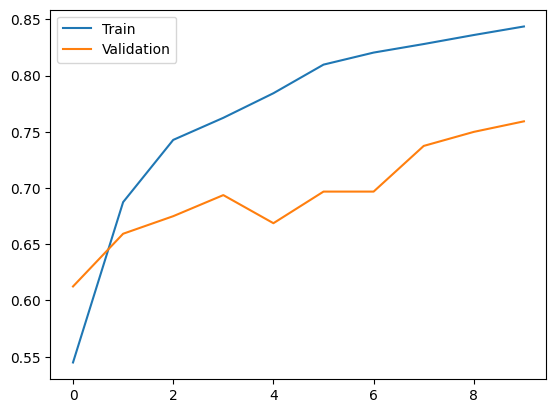

In [18]:
# Performance
# Plot Accuracy
plt.plot(history.history["accuracy"])

plt.plot(history.history["val_accuracy"])

plt.legend(["Train","Validation"])

plt.show()

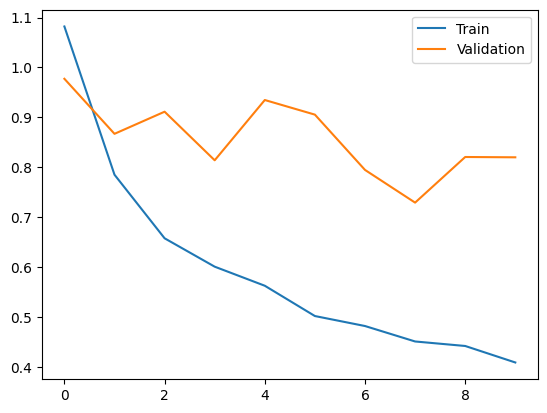

In [19]:
# Plot LOss
plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.legend(["Train","Validation"])

plt.show()

In [20]:
# Evaluate
loss,accuracy=model.evaluate(validation_generator)

print(accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 654ms/step - accuracy: 0.7469 - loss: 0.8435
0.746874988079071


In [22]:
# Save Model
model.save("brain_tumor_model.keras")

In [23]:
# Prediction
# Load Model
from tensorflow.keras.models import load_model

model=load_model("brain_tumor_model.keras")

In [24]:
from tensorflow.keras.preprocessing import image

# NOTE: The original error was FileNotFoundError because the image 'Multiple-Views-Of-Brain-MRI-Results-1024x499.webp'
# was not found directly in the 'Training' folder. Your images are likely in subdirectories
# like 'glioma', 'meningioma', 'notumor', 'pituitary' within the Training folder.
# You need to provide the correct path to an actual image file from one of those subfolders.
# For example, if you have an image 'image_0001.jpg' in the 'glioma' folder, the path would be:
# "/content/drive/MyDrive/Brain_Tumor/Training/glioma/image_0001.jpg"

# Please replace the placeholder path below with the actual path to an image file from your dataset.
img = image.load_img(
    "/content/drive/MyDrive/Brain_Tumor/Training/glioma/Tr-gl_1387.jpg", # Updated with a valid image name
    target_size=(224, 224)
)

img = image.img_to_array(img)
img = img / 255

In [25]:
import os

# List files in the 'glioma' directory to find an actual image file name
print(os.listdir('/content/drive/MyDrive/Brain_Tumor/Training/glioma'))

['Tr-gl_1387.jpg', 'Tr-gl_166.jpg', 'Tr-gl_1373.jpg', 'Tr-gl_153.jpg', 'Tr-gl_1365.jpg', 'Tr-gl_1357.jpg', 'Tr-gl_1298.jpg', 'Tr-gl_1348.jpg', 'Tr-gl_161.jpg', 'Tr-gl_1324.jpg', 'Tr-gl_129.jpg', 'Tr-gl_141.jpg', 'Tr-gl_159.jpg', 'Tr-gl_1286.jpg', 'Tr-gl_1305.jpg', 'Tr-gl_1396.jpg', 'Tr-gl_130.jpg', 'Tr-gl_1307.jpg', 'Tr-gl_1288.jpg', 'Tr-gl_140.jpg', 'Tr-gl_1295.jpg', 'Tr-gl_1275.jpg', 'Tr-gl_157.jpg', 'Tr-gl_132.jpg', 'Tr-gl_1306.jpg', 'Tr-gl_144.jpg', 'Tr-gl_1322.jpg', 'Tr-gl_152.jpg', 'Tr-gl_158.jpg', 'Tr-gl_1391.jpg', 'Tr-gl_1321.jpg', 'Tr-gl_1313.jpg', 'Tr-gl_1276.jpg', 'Tr-gl_1386.jpg', 'Tr-gl_1378.jpg', 'Tr-gl_1399.jpg', 'Tr-gl_1368.jpg', 'Tr-gl_145.jpg', 'Tr-gl_1362.jpg', 'Tr-gl_1328.jpg', 'Tr-gl_1375.jpg', 'Tr-gl_1372.jpg', 'Tr-gl_1360.jpg', 'Tr-gl_137.jpg', 'Tr-gl_1400.jpg', 'Tr-gl_1341.jpg', 'Tr-gl_1297.jpg', 'Tr-gl_1335.jpg', 'Tr-gl_1278.jpg', 'Tr-gl_1289.jpg', 'Tr-gl_1320.jpg', 'Tr-gl_13.jpg', 'Tr-gl_164.jpg', 'Tr-gl_1330.jpg', 'Tr-gl_1344.jpg', 'Tr-gl_1347.jpg', 'Tr-gl_16

In [26]:
# Prediction
import numpy as np

# Expand dimensions to create a batch of 1 image
img_batch = np.expand_dims(img, axis=0)
prediction = model.predict(img_batch)

classes=["Glioma",
"Meningioma",
"No Tumor",
"Pituitary"]

print(classes[np.argmax(prediction)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 859ms/step
Glioma


In [27]:
# Upload MRI
import streamlit as st

uploaded_file = st.file_uploader(

"Upload MRI",

type=["jpg","png","jpeg"]

)

2026-07-27 08:54:51.505 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-27 08:54:51.507 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-27 08:54:51.519 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-27 08:54:51.952 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-07-27 08:54:51.955 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-27 08:54:51.957 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [28]:
# Display Image
# Predict
if st.button("Predict"):

    prediction=model.predict(img)

    st.success(

    classes[np.argmax(prediction)]

    )

2026-07-27 08:54:54.209 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-27 08:54:54.210 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-27 08:54:54.212 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-27 08:54:54.212 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-27 08:54:54.214 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [29]:
# Confidence
confidence=np.max(prediction)*100

st.write(

f"Confidence : {confidence:.2f}%"

)

2026-07-27 08:54:56.600 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-27 08:54:56.601 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-27 08:54:56.602 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
